# Continuous housing investment with frictions: EGM(FUES) vs NEGM(FUES)

In [1]:
import warnings
warnings.filterwarnings('ignore', message='.*IProgress.*')

import numpy as np
import sys, os, time

REPO_ROOT = os.path.abspath('../../..')
sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)
os.environ['FUES_RETURN_GRIDS'] = '1'

from examples.durables.solve import solve
from examples.durables.horses.simulate import (
    simulate_lifecycle, evaluate_euler_c, evaluate_euler_h,
)
from examples.durables.outputs import (
    setup_nb_style,
    FilteredStdout, get_timing,
    print_solve_summary, build_comparison_row,
    nb_plot_adjuster_comparison, nb_plot_adjuster_egm,
    nb_plot_keeper_egm, nb_plot_keeper_policy,
    plot_euler_histogram, plot_lifecycle,
    compute_euler_stats,
    generate_vertical_comparison,
    generate_cohort_table,
    nb_plot_value_functions,
)
from IPython.display import Markdown

setup_nb_style()
SYNTAX = 'examples/durables/mod/separable'
print('Ready')

Ready


## 2. Solve

In [ ]:
OVERRIDES = dict(
    setting_overrides={
        'store_cntn': 1, 'N_wage': 6,
        'n_w': 600, 'n_a': 600, 'n_h': 600, 'n_sections': 1   
    },
    calib_overrides={
        't0': 20, 'tau': 0.07
    },
)

labels = {'FUES': 'EGM(FUES)', 'NEGM': 'NEGM(FUES)'}
results = {}
real_stdout = sys.stdout
for method in ['FUES', 'NEGM']:
    print(f'{labels[method]}', flush=True)
    t0 = time.time()
    sys.stdout = FilteredStdout(real_stdout)
    try:
        nest, grids = solve(
            SYNTAX, method=method,
            verbose=False, progress='bar',
            **OVERRIDES)
    finally:
        sys.stdout = real_stdout
    elapsed = time.time() - t0
    timing = get_timing(nest)
    results[method] = {
        'nest': nest, 'grids': grids,
        'timing': timing, 'elapsed': elapsed,
    }

print_solve_summary(results)

EGM(FUES)


    solve(method=...) is deprecated; use method_overrides instead.
    Settings symbol 'extrap_policy' (for cntn_to_dcsn_mover.extrap_policy) not declared in stage symbols.settings
    Settings symbol 'extrap_policy' (for dcsn_to_arvl_mover.extrap_policy) not declared in stage symbols.settings
    Settings symbol 'n_sections' (for cntn_to_dcsn_mover.n_sections) not declared in stage symbols.settings
Solving:  25%|██▌       | 13/51 [00:22<00:37,  1.01it/s, age=58, avg_adj_ms=50, avg_keeper_ms=239]

## 3. Adjuster policies

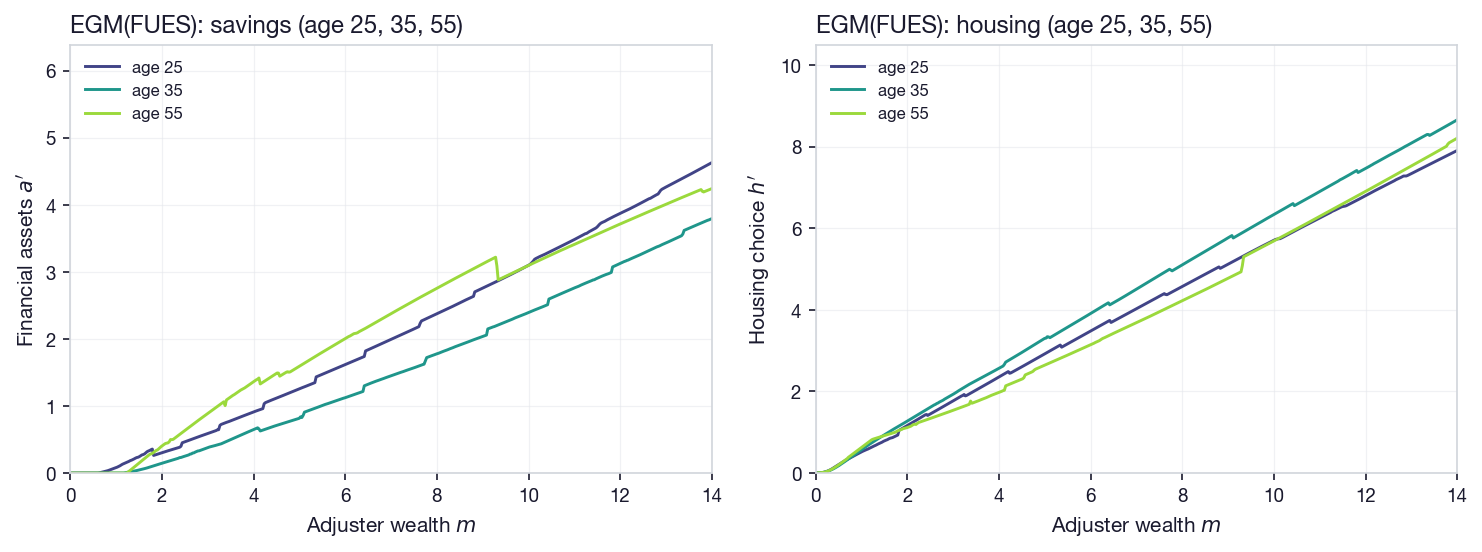

In [ ]:
fig = nb_plot_adjuster_comparison(
    results, results['FUES']['grids'],
    plot_t=[25, 35, 55], methods_filter=['FUES'], i_z=0)

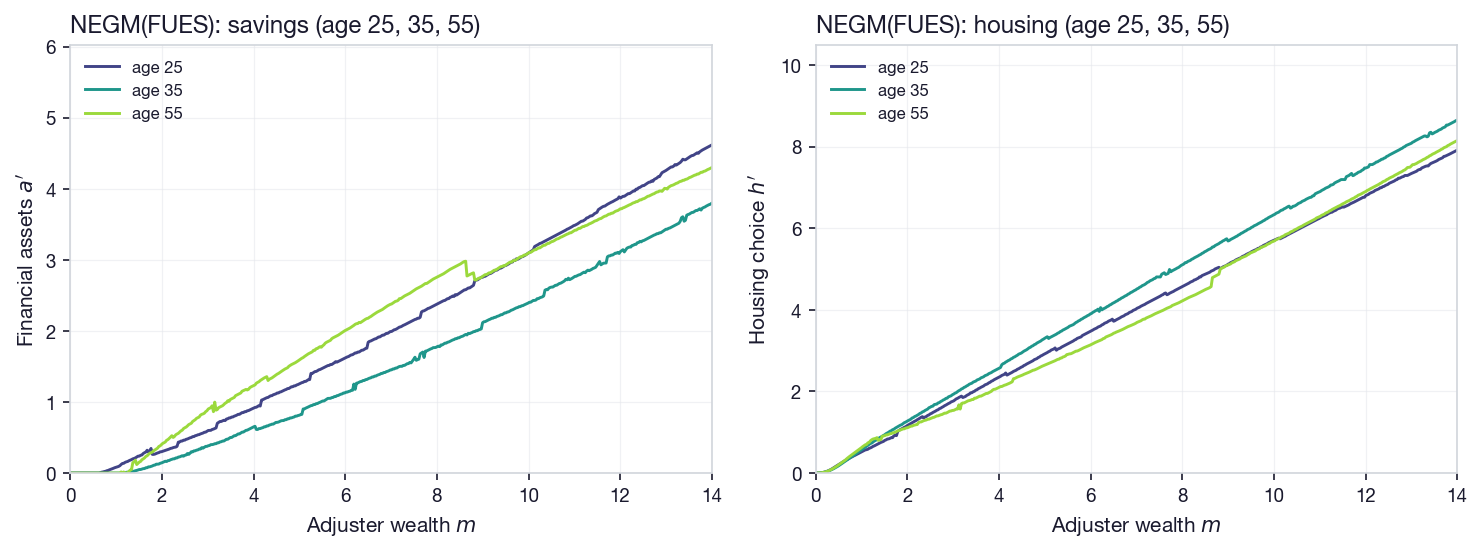

In [ ]:
fig = nb_plot_adjuster_comparison(
    results, results['NEGM']['grids'],
    plot_t=[25, 35, 55], methods_filter=['NEGM'], i_z=0)

#fig = nb_plot_value_functions(
#    results, results['FUES']['grids'], plot_t=67)


## 4. Adjuster EGM grid

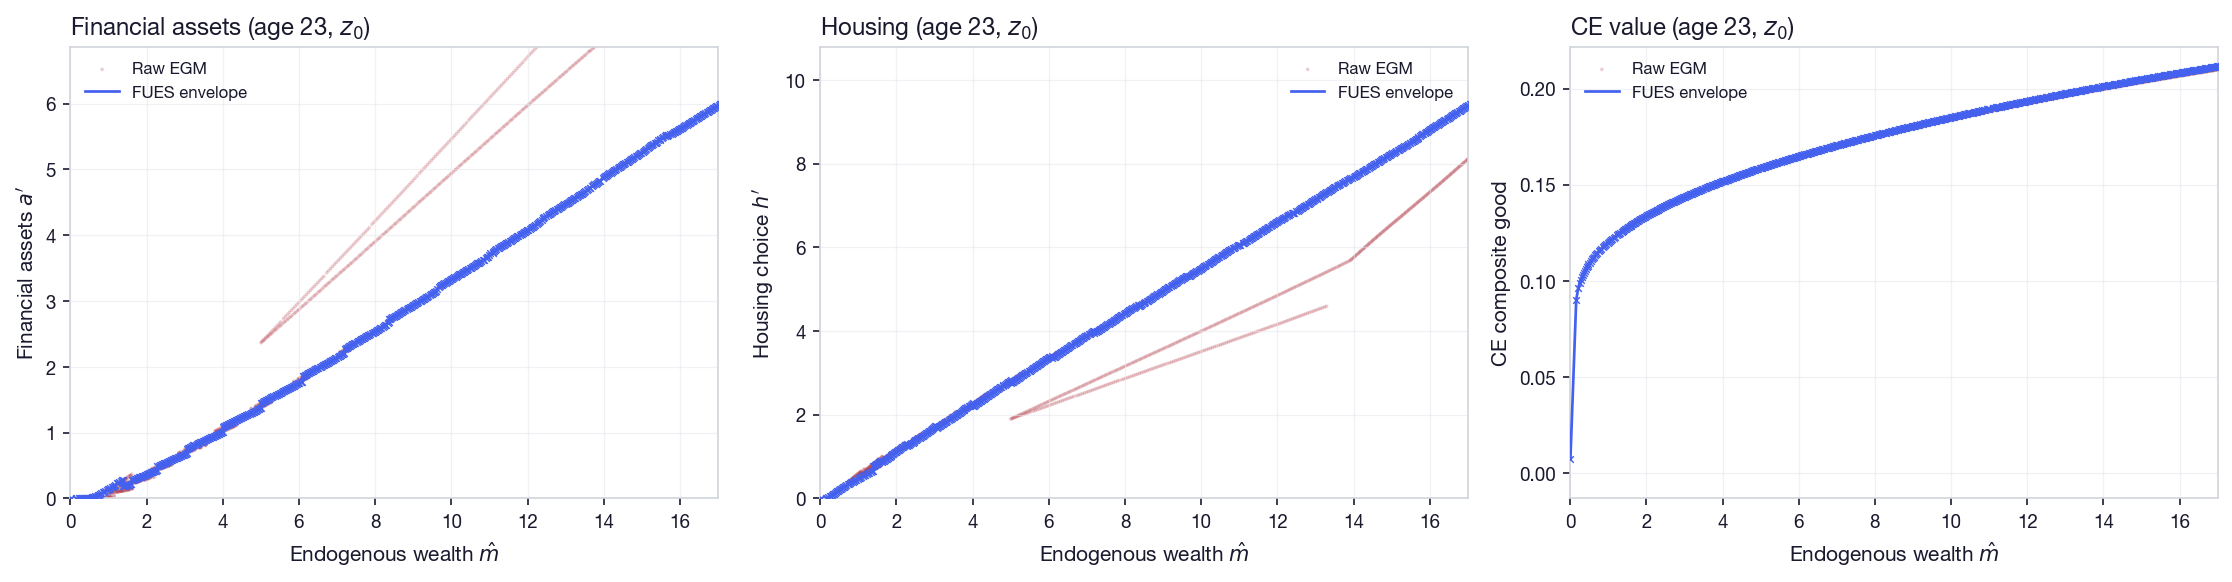

In [ ]:
fig = nb_plot_adjuster_egm(
    results['FUES']['nest'],
    results['FUES']['grids'], plot_t=23, xlim =17)

In [ ]:
# ── Interactive plotly (zoom/pan to inspect dense crossings) ──
try:
    from examples.durables.outputs import nb_plot_adjuster_egm_interactive
    fig_a, fig_h, fig_v = nb_plot_adjuster_egm_interactive(
        results['FUES']['nest'], results['FUES']['grids'], plot_t=55, i_z=0)
    fig_a.show()
    fig_h.show()
    fig_v.show()
except Exception as e:
    print(f'Interactive plots skipped: {e}')

## 5. Keeper policies

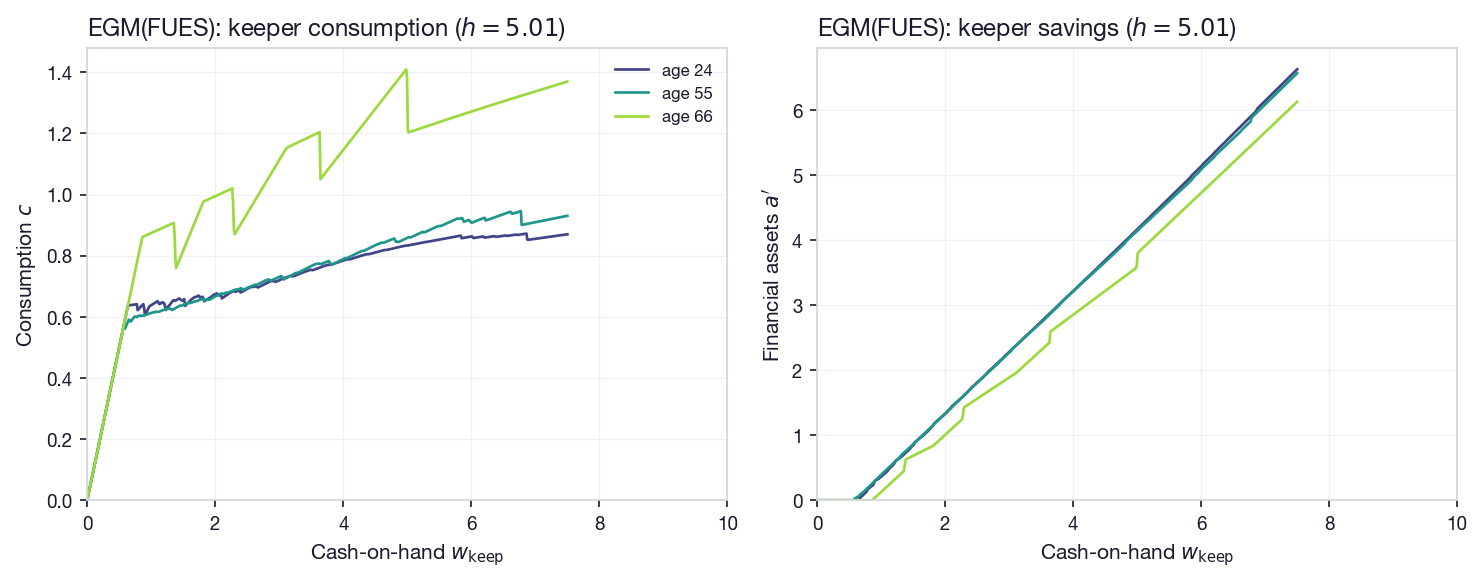

In [ ]:
fig = nb_plot_keeper_policy(results, results['FUES']['grids'],
                           plot_t=[24, 55, 66], methods_filter=['FUES'], xlim=7.5)

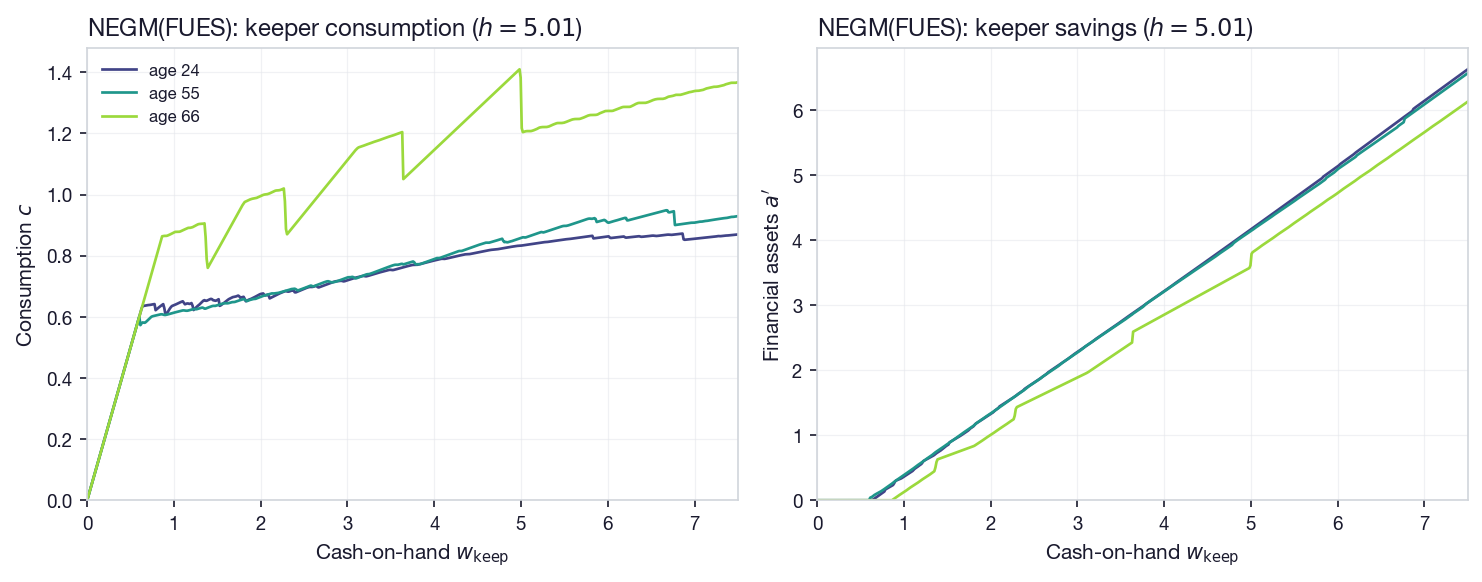

In [ ]:
fig = nb_plot_keeper_policy(results, results['NEGM']['grids'],
                           plot_t=[24, 55, 66], methods_filter=['NEGM'])

## 6. Euler equation errors

In [ ]:
euler_results = {}

for method in ['FUES', 'NEGM']:
    r = results[method]
    sim_data = simulate_lifecycle(r['nest'], r['grids'], N=20_000, seed=21, init_dispersion=0.5)       
    euler_c = evaluate_euler_c(sim_data, r['nest'], r['grids'])
    euler_h = evaluate_euler_h(sim_data, r['nest'], r['grids'])
    euler_results[method] = {
        'euler_c': euler_c, 'euler_h': euler_h, 'euler': euler_c,
        'stats_c': compute_euler_stats(euler_c, sim_data['discrete']),
        'stats_h': compute_euler_stats(euler_h, sim_data['discrete']),
        'stats': compute_euler_stats(euler_c, sim_data['discrete']),
        'sim_data': sim_data,
    }

print('Simulation complete (N = 10,000)')

Simulation complete (N = 10,000)


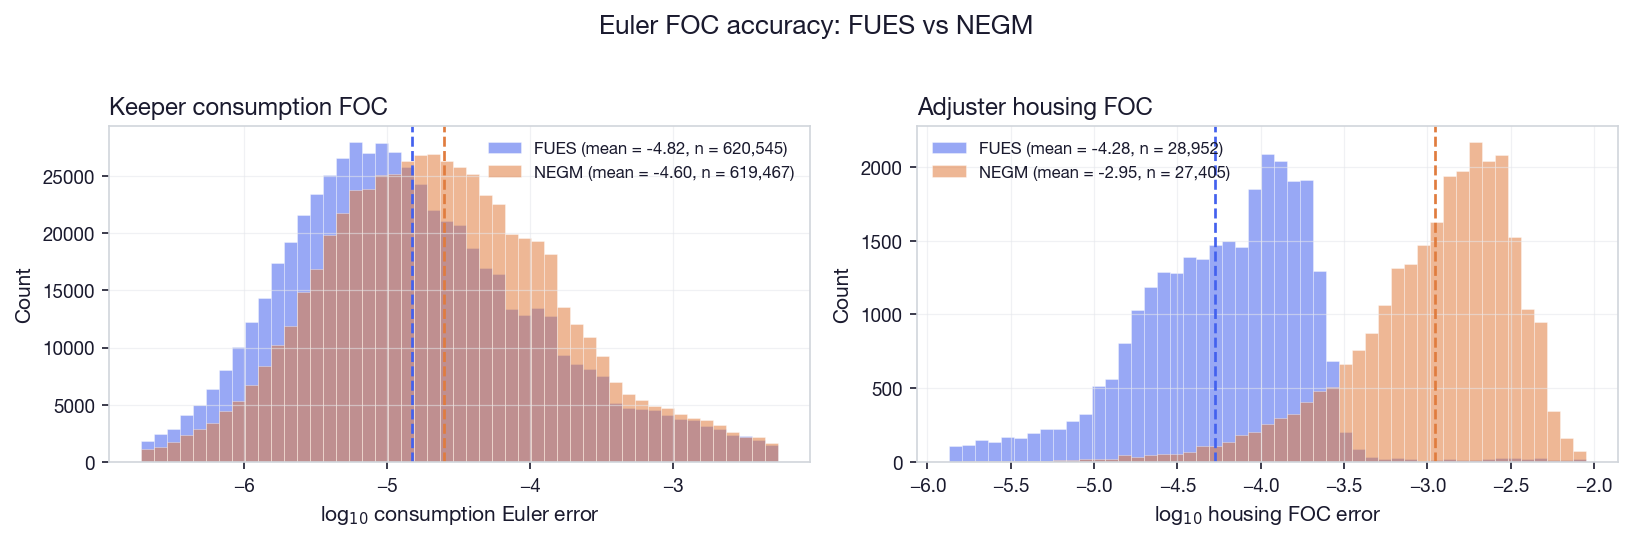

In [ ]:
fig = plot_euler_histogram(euler_results)

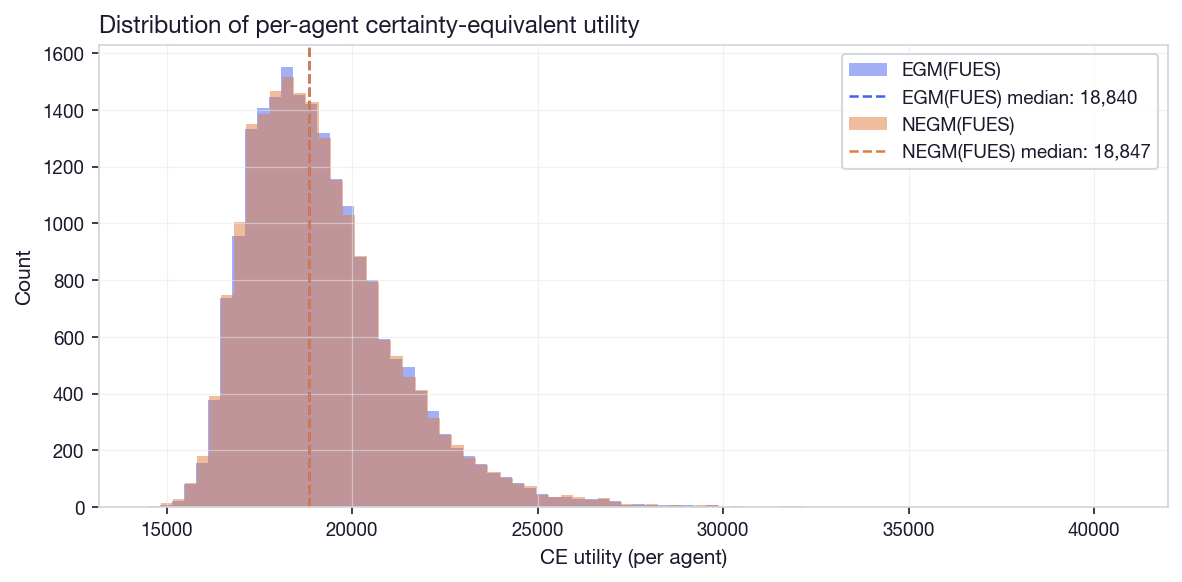

200 agents in bottom 1%
  agent 172: diverges at age 0, d_fues=-1, d_negm=-1, c_fues=nan, c_negm=nan
  agent 408: diverges at age 0, d_fues=-1, d_negm=-1, c_fues=nan, c_negm=nan
  agent 469: diverges at age 56, d_fues=0, d_negm=0, c_fues=0.5635, c_negm=0.5750
  agent 660: diverges at age 0, d_fues=-1, d_negm=-1, c_fues=nan, c_negm=nan
  agent 878: diverges at age 0, d_fues=-1, d_negm=-1, c_fues=nan, c_negm=nan
Agent 469 at age 38: a=0.2521, h=2.1829, z_idx=1
  EGM(FUES): adj_interp=0.000000 -> d=0
  NEGM(FUES): adj_interp=0.000000 -> d=0


In [ ]:
# ── Per-agent CE utility histogram ──
import matplotlib.pyplot as plt

_st = results['FUES']['nest']['periods'][0]['stages']['keeper_cons']
_rho = float(_st.calibration.get('gamma_c', _st.calibration.get('rho', 2.0)))
_norm = 1.0 / float(_st.settings['normalisation'])
_labels = {'FUES': 'EGM(FUES)', 'NEGM': 'NEGM(FUES)'}
_colors = {'FUES': '#4361ee', 'NEGM': '#e07c3e'}

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
for method in ['FUES', 'NEGM']:
    npv = euler_results[method]['sim_data']['npv_utility']
    valid = npv[np.isfinite(npv) & (npv != 0)]
    inner = (1.0 - _rho) * valid
    ce = np.where(inner > 0, inner ** (1.0 / (1.0 - _rho)), np.nan) * _norm
    ce = ce[np.isfinite(ce)]
    ax.hist(ce, bins=80, alpha=0.5, label=_labels[method], color=_colors[method])
    ax.axvline(np.median(ce), color=_colors[method], ls='--', lw=1.2,
               label=f'{_labels[method]} median: {np.median(ce):,.0f}')

ax.set_xlabel('CE utility (per agent)')
ax.set_ylabel('Count')
ax.set_title('Distribution of per-agent certainty-equivalent utility')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


# Find agents where FUES CE << NEGM CE                                                                                                                                                                                                                                                                                   
sd_f = euler_results['FUES']['sim_data']                  
sd_n = euler_results['NEGM']['sim_data']                                                                                                                                                                                                                                                                                 
npv_f = sd_f['npv_utility']
npv_n = sd_n['npv_utility']                                                                                                                                                                                                                                                                                              
# agents where FUES NPV is much worse                     
bad = np.where(npv_f < np.percentile(npv_f, 1))[0]                                                                                                                                                                                                                                                                       
print(f"{len(bad)} agents in bottom 1%")                                                                                                                                                                                                                                                                                 
# first period where c diverges significantly                                                                                                                                                                                                                                                                            
for i in bad[:5]:                                                                                                                                                                                                                                                                                                        
    diff = np.abs(sd_f['c'][:, i] - sd_n['c'][:, i])                                                                                                                                                                                                                                                                     
    t_div = np.nanargmax(diff > 0.01)                                                                                                                                                                                                                                                                                    
    print(f"  agent {i}: diverges at age {t_div}, "                                                                                                                                                                                                                                                                      
        f"d_fues={sd_f['discrete'][t_div,i]}, "         
        f"d_negm={sd_n['discrete'][t_div,i]}, "                                                                                                                                                                                                                                                                        
        f"c_fues={sd_f['c'][t_div,i]:.4f}, "                                                                                                                                                                                                                                                                           
        f"c_negm={sd_n['c'][t_div,i]:.4f}") 


# ── Diagnose adjust/keep margin at divergence points ──                                                                                                                                                                                                                                                                 
sd_f = euler_results['FUES']['sim_data']                                                                                                                                                                                                                                                                                 
sd_n = euler_results['NEGM']['sim_data']                                                                                                                                                                                                                                                                                 
npv_f = sd_f['npv_utility']                                                                                                                                                                                                                                                                                              
bad = np.where(npv_f < np.percentile(npv_f, 1))[0]                                                                                                                                                                                                                                                                       
                                                                                                                                                                                                                                                                                                                        
# Pick one representative agent at the divergence age                                                                                                                                                                                                                                                                    
i = bad[2]  # agent 509                                                                                                                                                                                                                                                                                                  
t_div = 38                                                                                                                                                                                                                                                                                                               

a_i = sd_f['a'][t_div, i]                                                                                                                                                                                                                                                                                                
h_i = sd_f['h'][t_div, i]                                 
z_i = int(sd_f['z_idx'][t_div, i])                                                                                                                                                                                                                                                                                       
                                                        
print(f"Agent {i} at age {t_div}: a={a_i:.4f}, h={h_i:.4f}, z_idx={z_i}")                                                                                                                                                                                                                                                

# Look up the tenure discrete choice arrays for both methods                                                                                                                                                                                                                                                             
from interpolation.splines import eval_linear             
from interpolation.splines import extrap_options as xto                                                                                                                                                                                                                                                                  
                                                                                                                                                                                                                                                                                                                        
UG = results['FUES']['grids']['UGgrid_all']                                                                                                                                                                                                                                                                              
sol_by_t_f = {s['t']: s for s in results['FUES']['nest']['solutions']}                                                                                                                                                                                                                                                   
sol_by_t_n = {s['t']: s for s in results['NEGM']['nest']['solutions']}                                                                                                                                                                                                                                                   
                                                        
pt = np.array([a_i, h_i])                                                                                                                                                                                                                                                                                                
for method, sol_by_t, label in [                          
    ('FUES', sol_by_t_f, 'EGM(FUES)'),                                                                                                                                                                                                                                                                                   
    ('NEGM', sol_by_t_n, 'NEGM(FUES)')]:                  
    sol = sol_by_t[t_div]                                                                                                                                                                                                                                                                                                
    adj_arr = sol['tenure']['dcsn']['adj']                                                                                                                                                                                                                                                                               
    adj_val = eval_linear(UG, adj_arr[z_i], pt, xto.LINEAR)                                                                                                                                                                                                                                                              
    print(f"  {label}: adj_interp={adj_val:.6f} -> d={int(round(min(max(adj_val,0),1)))}") 


# ── Find first discrete-choice divergence ──                                                                                                                                                                                                                                                                            

                                                                                                                                                                                                                                                                                                                           
# Also check tenure arrival V (what feeds into next period's continuation)                                                                                                                                                                                                                                               
for sol in results['FUES']['nest']['solutions']:                                                                                                                                                                                                                                                                         
    t = sol['t']                                                                                                                                                                                                                                                                                                         
    arvl = sol['tenure'].get('arvl', {})                  
    V_arvl = arvl.get('V')                                                                                                                                                                                                                                                                                               
    if V_arvl is not None:
        n_pos = np.sum(V_arvl > 0)                                                                                                                                                                                                                                                                                       
        if n_pos > 0:                                                                                                                                                                                                                                                                                                    
            print(f"  age {t}: {n_pos} positive V in tenure arrival (max={V_arvl.max():.4f})")                                

In [ ]:
# Check for positive V in FUES adjuster (should all be negative for gamma > 1)                                                                                                                                                                                                                                           
for sol in results['FUES']['nest']['solutions']:                                                                                                                                                                                                                                                                         
    t = sol['t']                                                                                                                                                                                                                                                                                                         
    V_adj = sol['adjuster_cons']['dcsn'].get('V')                                                                                                                                                                                                                                                                        
    if V_adj is not None:                                 
        n_pos = np.sum(V_adj > 0)                                                                                                                                                                                                                                                                                        
        if n_pos > 0:                                     
            print(f"  age {t}: {n_pos} positive V in adjuster (max={V_adj.max():.4f})")
                                                                                                                                                                                                                                                                                                                        
# Also check tenure arrival V (what feeds into next period's continuation)                                                                                                                                                                                                                                               
for sol in results['FUES']['nest']['solutions']:                                                                                                                                                                                                                                                                         
    t = sol['t']                                                                                                                                                                                                                                                                                                         
    arvl = sol['tenure'].get('arvl', {})                  
    V_arvl = arvl.get('V')                                                                                                                                                                                                                                                                                               
    if V_arvl is not None:
        n_pos = np.sum(V_arvl > 0)                                                                                                                                                                                                                                                                                       
        if n_pos > 0:                                                                                                                                                                                                                                                                                                    
            print(f"  age {t}: {n_pos} positive V in tenure arrival (max={V_arvl.max():.4f})")

## 7. Comparison of aggregates

In [ ]:
rows = [build_comparison_row(m, results, euler_results)
        for m in ['FUES', 'NEGM']]
Markdown(generate_vertical_comparison(
    rows, caption='EGM(FUES) vs NEGM(FUES)'))

### EGM(FUES) vs NEGM(FUES)

| | **EGM(FUES)** | **NEGM(FUES)** |
|:---|:---:|:---:|
| **Timing** |  |  |
| Keeper (ms/period) | 225 | 447 |
| Adjuster (ms/period) | 33 | 50 |
| Total (ms/period) | 963 | 1405 |
| **Euler errors ($\log_{10}$)** |  |  |
| Consumption: keeper | -4.82 | -4.60 |
| Consumption: adjuster | -4.23 | -4.19 |
| Consumption: all | -4.80 | -4.59 |
| Housing: adjuster | -4.28 | -2.95 |
| **Simulation** |  |  |
| CE utility | 18,871.28 | 18,874.15 |
| Mean consumption ($) | 62,656 | 62,644 |
| Mean fin. assets ($) | 67,476 | 67,159 |
| Mean housing ($) | 247,519 | 247,880 |
| Adjustment rate (%) | 14.9 | 15.2 |

## 8. Lifecycle profiles

Lifecycle plot saved to _nb_plots/FUES/simulation/lifecycle.png
EGM(FUES)


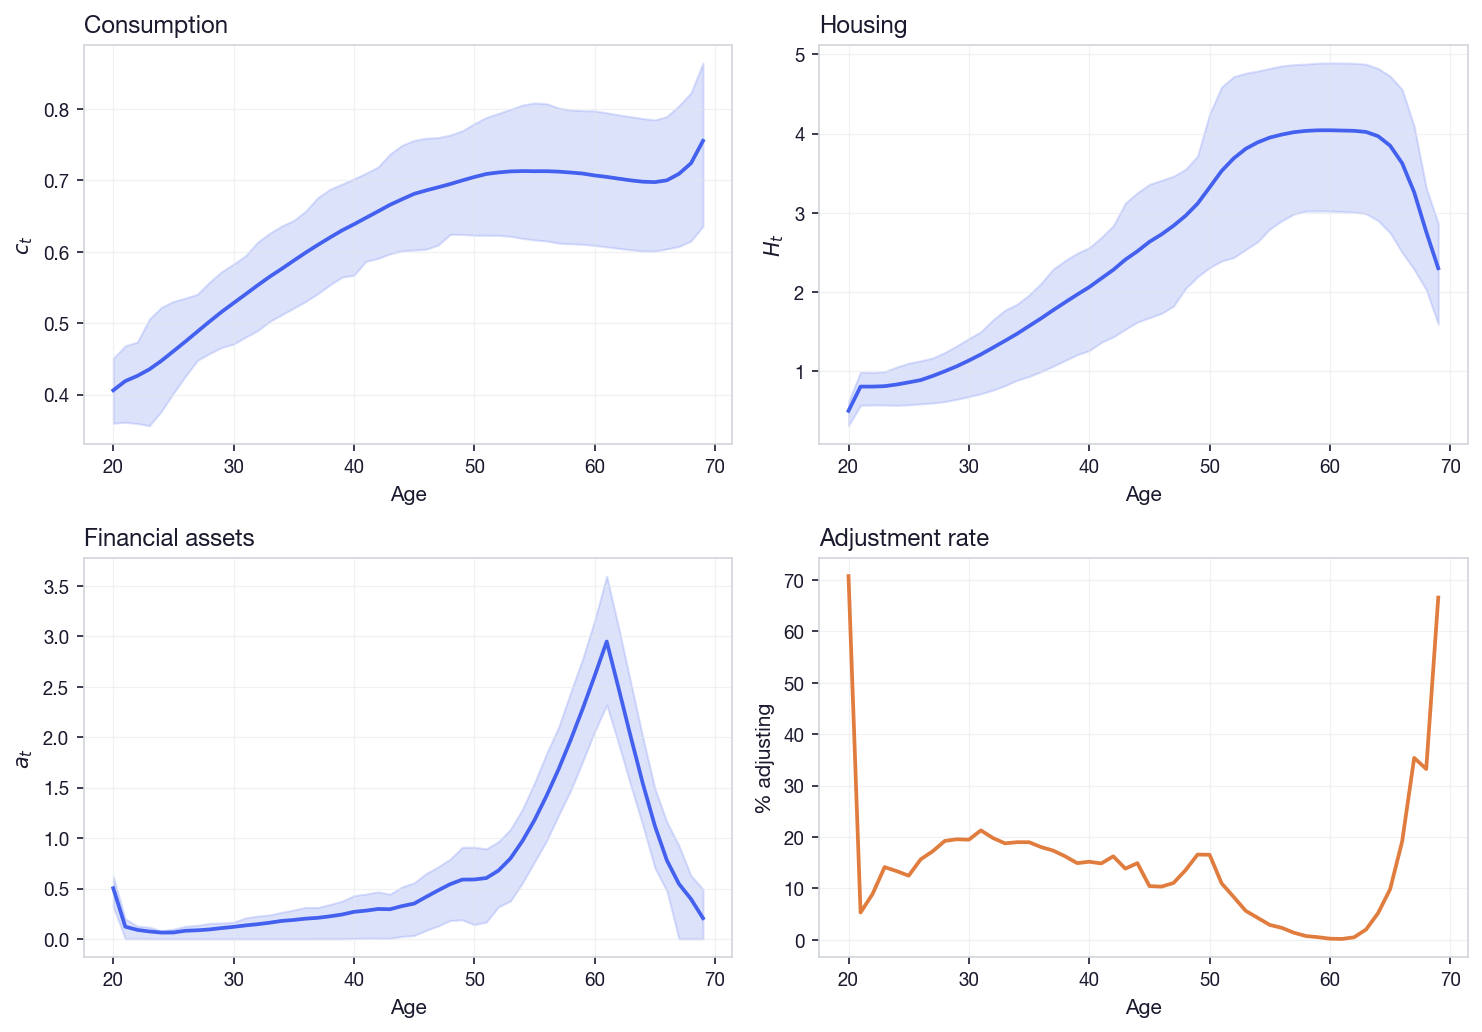

Lifecycle plot saved to _nb_plots/NEGM/simulation/lifecycle.png
NEGM(FUES)


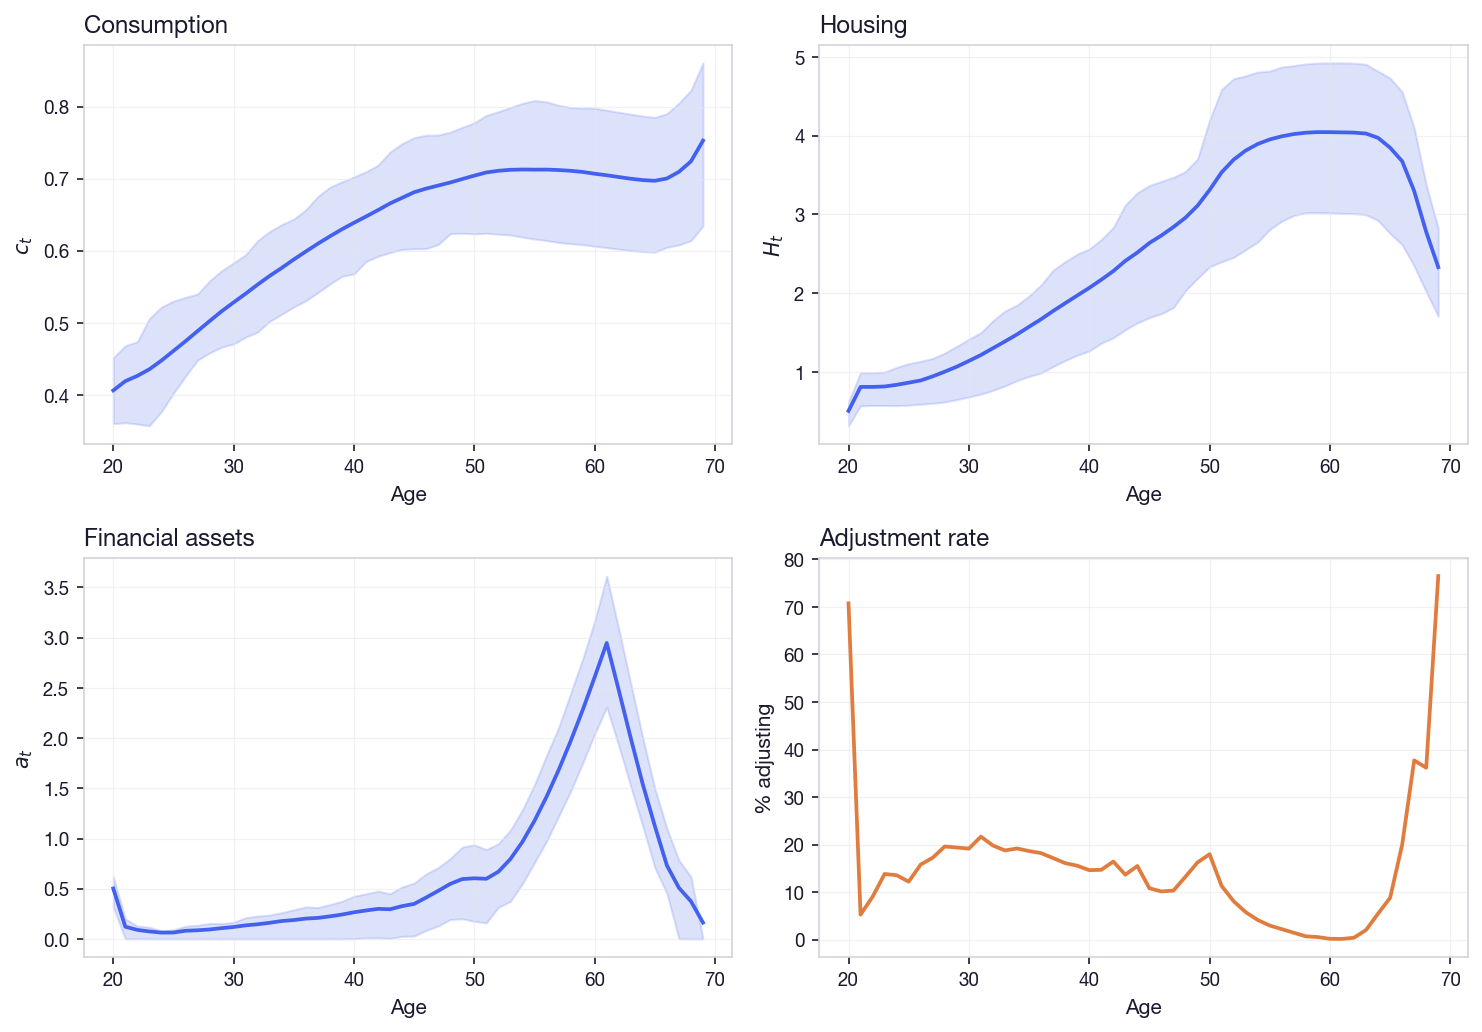

In [ ]:
from IPython.display import Image, display

for method in ['FUES', 'NEGM']:
    er = euler_results[method]
    r = results[method]
    plot_lifecycle(er['sim_data'], er['euler'], r['nest'],
                   output_dir=f'_nb_plots/{method}')
    path = f'_nb_plots/{method}/simulation/lifecycle.png'
    if os.path.exists(path):
        print(f'{labels[method]}')
        display(Image(path))

In [ ]:
_st0 = results['FUES']['nest']['periods'][0]['stages']['keeper_cons']
_t0 = int(_st0.calibration['t0'])
_T = int(_st0.settings['T'])
_norm = 1.0 / float(_st0.settings['normalisation'])
labels = {'FUES': 'EGM(FUES)', 'NEGM': 'NEGM(FUES)'}

for method in ['FUES', 'NEGM']:
    sd = euler_results[method]['sim_data']
    tbl = generate_cohort_table(sd, _t0, _T, _norm)
    display(Markdown(f'**{labels[method]}**\n\n{tbl}'))

**EGM(FUES)**

| Age | $\bar{c}$ | SD($c$) | $\bar{a}$ | SD($a$) | $\bar{H}$ | SD($H$) |
|:---|---:|---:|---:|---:|---:|---:|
| 20–24 | 42,679.46 | 7,814.18 | 17,020.44 | 23,034.95 | 75,352.17 | 34,694.04 |
| 25–29 | 48,835.30 | 8,709.12 | 8,658.17 | 13,112.57 | 95,228.86 | 45,410.83 |
| 30–34 | 55,266.86 | 8,839.15 | 14,798.61 | 19,708.08 | 130,212.41 | 64,158.58 |
| 35–39 | 60,925.12 | 9,126.98 | 21,305.91 | 25,790.37 | 177,066.23 | 82,750.77 |
| 40–44 | 65,646.29 | 9,415.63 | 29,337.23 | 33,330.05 | 228,801.95 | 100,635.22 |
| 45–49 | 69,048.45 | 9,867.29 | 47,630.26 | 45,162.16 | 285,529.85 | 117,753.77 |
| 50–54 | 71,011.92 | 11,169.43 | 72,800.54 | 56,158.98 | 364,600.70 | 138,651.09 |
| 55–59 | 71,174.06 | 12,543.11 | 170,627.50 | 78,973.83 | 400,525.81 | 140,737.67 |
| 60–64 | 70,250.14 | 12,777.78 | 231,610.24 | 95,354.81 | 401,991.97 | 141,543.55 |
| 65–69 | 71,724.99 | 13,911.33 | 60,973.43 | 55,365.09 | 315,877.30 | 133,897.81 |

**NEGM(FUES)**

| Age | $\bar{c}$ | SD($c$) | $\bar{a}$ | SD($a$) | $\bar{H}$ | SD($H$) |
|:---|---:|---:|---:|---:|---:|---:|
| 20–24 | 42,682.98 | 7,812.10 | 17,049.61 | 23,042.71 | 75,328.42 | 34,694.96 |
| 25–29 | 48,834.62 | 8,704.79 | 8,664.52 | 13,119.26 | 95,218.99 | 45,432.36 |
| 30–34 | 55,259.66 | 8,847.88 | 14,796.58 | 19,684.12 | 130,225.98 | 64,201.59 |
| 35–39 | 60,926.79 | 9,124.98 | 21,365.66 | 25,829.61 | 177,042.39 | 82,747.12 |
| 40–44 | 65,638.60 | 9,420.95 | 29,420.91 | 33,340.79 | 228,780.68 | 100,657.56 |
| 45–49 | 69,046.43 | 9,882.82 | 47,700.35 | 45,216.79 | 285,521.45 | 117,530.56 |
| 50–54 | 70,982.05 | 11,164.16 | 72,723.49 | 56,640.99 | 364,861.65 | 138,173.80 |
| 55–59 | 71,152.31 | 12,548.86 | 170,415.84 | 78,912.74 | 400,920.11 | 140,774.27 |
| 60–64 | 70,239.38 | 12,769.95 | 231,411.60 | 95,283.13 | 402,449.17 | 141,454.43 |
| 65–69 | 71,678.03 | 13,926.34 | 58,045.78 | 54,605.87 | 318,453.48 | 132,336.16 |